In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

In [2]:
STRATEGY_TAG = "qffl_q2p0"
csv_path = Path(f"../fairness_results/model_federated_{STRATEGY_TAG}/fairness_log.csv")
jsonl_path = Path(f"../fairness_results/model_federated_{STRATEGY_TAG}/fairness_metrics.jsonl")

df = pd.read_csv(csv_path)
df.head()

,round,client_id,num_examples,valid_loss
0,1,5,261,800.643799
1,1,0,201,1361.651611
2,1,1,128,6126.099121
3,1,6,298,3482.686035
4,1,2,387,736.164978


In [3]:
final_round = df["round"].max()
final_df = df[df["round"] == final_round].sort_values("client_id")
final_df

,round,client_id,num_examples,valid_loss
65,10,0,201,1235.159790
63,10,1,128,4659.880859
68,10,2,387,729.715332
67,10,3,345,673.568298
69,10,4,721,743.070068
64,10,5,261,838.613892
66,10,6,298,2813.795410


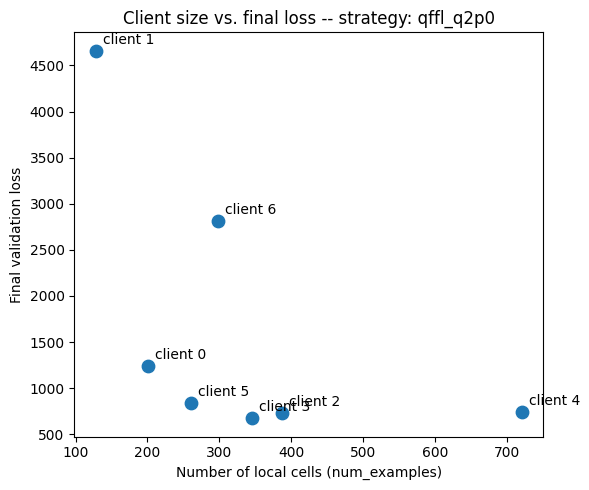

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(final_df["num_examples"], final_df["valid_loss"], s=80)
for _, row in final_df.iterrows():
    ax.annotate(f"client {int(row['client_id'])}", (row["num_examples"], row["valid_loss"]),
                 textcoords="offset points", xytext=(5, 5))
ax.set_xlabel("Number of local cells (num_examples)")
ax.set_ylabel("Final validation loss")
ax.set_title(f"Client size vs. final loss -- strategy: {STRATEGY_TAG}")
plt.tight_layout()
plt.show()

In [5]:
r_pearson, p_pearson = pearsonr(final_df["num_examples"], final_df["valid_loss"])
r_spearman, p_spearman = spearmanr(final_df["num_examples"], final_df["valid_loss"])
print(f"Pearson  r = {r_pearson:.3f}  (p = {p_pearson:.3f})")
print(f"Spearman r = {r_spearman:.3f}  (p = {p_spearman:.3f})")

Pearson  r = -0.549  (p = 0.202)
Spearman r = -0.750  (p = 0.052)


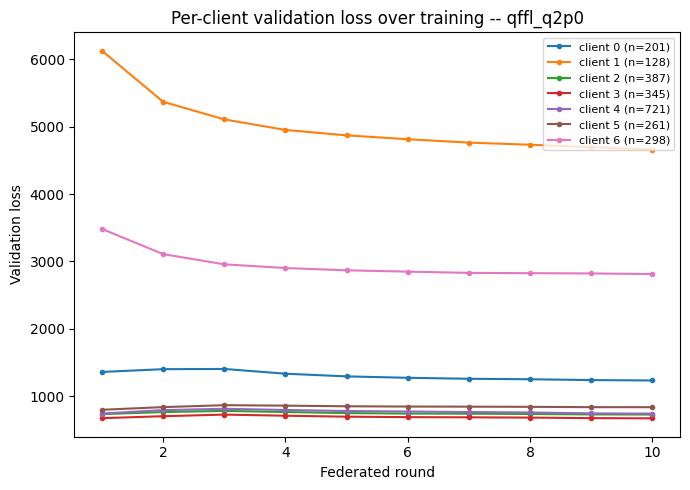

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
sizes = df.groupby("client_id")["num_examples"].first()
for client_id, group in df.groupby("client_id"):
    ax.plot(group["round"], group["valid_loss"],
            label=f"client {client_id} (n={sizes[client_id]})", marker="o", markersize=3)
ax.set_xlabel("Federated round")
ax.set_ylabel("Validation loss")
ax.set_title(f"Per-client validation loss over training -- {STRATEGY_TAG}")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

In [7]:
lib_df = pd.read_csv("client_library_sizes.csv")
lib_df

,client_id,n_cells,mean_lib_size,median_lib_size
0,0,201,10268.771484,10022.187500
1,1,128,10961.942383,10981.234375
2,2,387,7506.309570,7502.605469
3,3,345,7187.620117,7230.340820
4,4,721,7196.999512,7199.510742
5,5,261,8246.619141,8177.386230
6,6,298,10910.443359,11073.988281


In [8]:
merged = final_df.merge(lib_df, on="client_id", how="left", suffixes=("", "_lib"))

merged["normalized_loss"] = merged["valid_loss"] / merged["mean_lib_size"]
merged[["client_id", "num_examples", "mean_lib_size", "valid_loss", "normalized_loss"]]

,client_id,num_examples,mean_lib_size,valid_loss,normalized_loss
0,0,201,10268.771484,1235.159790,0.120283
1,1,128,10961.942383,4659.880859,0.425096
2,2,387,7506.309570,729.715332,0.097214
3,3,345,7187.620117,673.568298,0.093712
4,4,721,7196.999512,743.070068,0.103247
5,5,261,8246.619141,838.613892,0.101692
6,6,298,10910.443359,2813.795410,0.257899


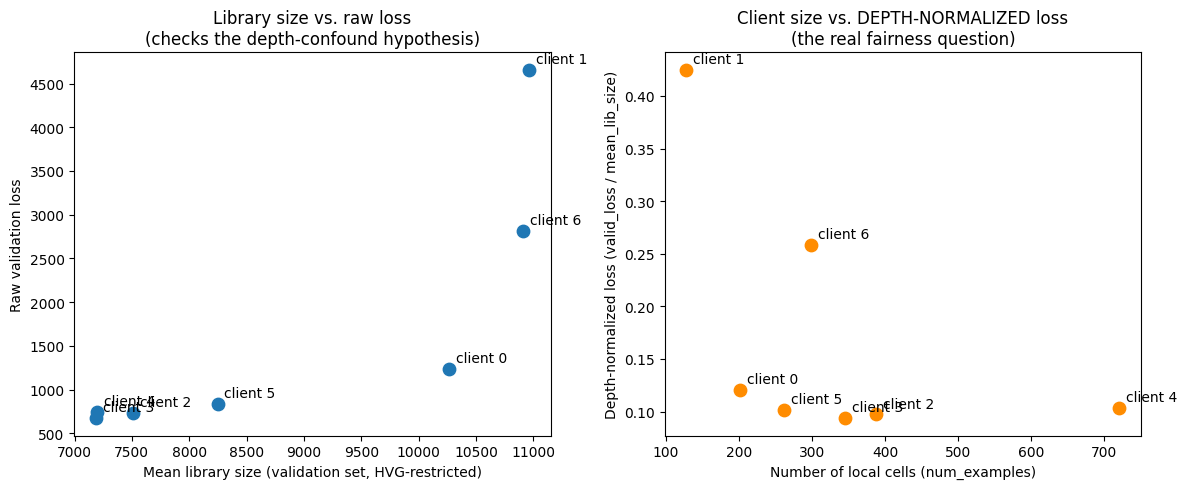

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(merged["mean_lib_size"], merged["valid_loss"], s=80)
for _, row in merged.iterrows():
    axes[0].annotate(f"client {int(row['client_id'])}", (row["mean_lib_size"], row["valid_loss"]),
                      textcoords="offset points", xytext=(5, 5))
axes[0].set_xlabel("Mean library size (validation set, HVG-restricted)")
axes[0].set_ylabel("Raw validation loss")
axes[0].set_title("Library size vs. raw loss\n(checks the depth-confound hypothesis)")

axes[1].scatter(merged["num_examples"], merged["normalized_loss"], s=80, color="darkorange")
for _, row in merged.iterrows():
    axes[1].annotate(f"client {int(row['client_id'])}", (row["num_examples"], row["normalized_loss"]),
                      textcoords="offset points", xytext=(5, 5))
axes[1].set_xlabel("Number of local cells (num_examples)")
axes[1].set_ylabel("Depth-normalized loss (valid_loss / mean_lib_size)")
axes[1].set_title("Client size vs. DEPTH-NORMALIZED loss\n(the real fairness question)")

plt.tight_layout()
plt.show()

In [10]:
r_lib, p_lib = pearsonr(merged["mean_lib_size"], merged["valid_loss"])
r_norm, p_norm = pearsonr(merged["num_examples"], merged["normalized_loss"])

print(f"Library size vs. raw loss:        Pearson r = {r_lib:.3f}  (p = {p_lib:.3f})")
print(f"Client size vs. normalized loss:  Pearson r = {r_norm:.3f}  (p = {p_norm:.3f})")

Library size vs. raw loss:        Pearson r = 0.815  (p = 0.025)
Client size vs. normalized loss:  Pearson r = -0.516  (p = 0.236)


In [12]:
def jain_index(values):
    v = np.array(values, dtype=float)
    sq_sum = (v ** 2).sum()
    return float((v.sum() ** 2) / (len(v) * sq_sum)) if sq_sum > 0 else 1.0

print(f"Jain's index, raw loss:        {jain_index(merged['valid_loss']):.3f}")
print(f"Jain's index, normalized loss: {jain_index(merged['normalized_loss']):.3f}")

Jain's index, raw loss:        0.585
Jain's index, normalized loss: 0.683
